# B6 (partie 2) — Auto-encodeur TensorFlow/Keras, entraînement CPU (catégorie `wood`)

## Objectif concret

Entraîner un auto-encodeur convolutif en **TensorFlow/Keras** sur les images saines de `wood`
préparées en partie 1, calibrer un seuil d'anomalie sur la validation, puis évaluer la détection sur
le test (saines + défauts). Ce notebook sert de point de comparaison à
[`02b-autoencoder-pytorch-cpu.ipynb`](02b-autoencoder-pytorch-cpu.ipynb) et
[`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb) — même architecture, mêmes
hyperparamètres, même jeu de données. La comparaison chiffrée est faite dans
[`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb).

Ce notebook réutilise sans les ré-expliquer les notions de la partie 1 — voir
[`01-preparation-donnees-augmentation-wood.ipynb`](01-preparation-donnees-augmentation-wood.ipynb).

## Prérequis

- **Noyau Jupyter** : sélectionner **`Python 3.13 (indusense, TensorFlow)`** (`indusense-py313-tf`),
  pas le noyau `python3` par défaut. TensorFlow n'a pas de roue Python 3.14 au moment de ce TP (voir
  la fiche de révision correspondante).
- TensorFlow n'a **pas** de support GPU natif sous Windows (≥ 2.11) : cet entraînement est donc
  nécessairement CPU, quel que soit le GPU disponible sur la machine.

## Architecture (identique en TensorFlow et PyTorch, CPU et GPU)

Auto-encodeur convolutif symétrique à 3 niveaux, entrée/sortie `256×256×3` :

| Bloc | Couches | Canaux |
|---|---|---|
| Encodeur | `Conv 3×3, stride 2` ×3 (+ ReLU) | `3 → 64 → 128 → 256` |
| Goulot d'étranglement | — | `32×32×256` |
| Décodeur | `ConvTranspose 3×3, stride 2` ×3 (+ ReLU, puis Sigmoid en sortie) | `256 → 128 → 64 → 3` |

La sortie `Sigmoid` produit des valeurs dans `[0, 1]`. La perte est l'**erreur quadratique moyenne
(MSE)** entre l'image d'entrée et sa reconstruction : c'est elle qui, calculée par image sur le test,
sert de **score d'anomalie**.

In [1]:
from pathlib import Path
import time

import numpy as np
import tensorflow as tf

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)
print(f'TensorFlow {tf.__version__} ; GPU visibles : {tf.config.list_physical_devices("GPU")}')

from indusense.vision.dataset import (
    list_defect_categories, list_image_paths, load_image_batch,
    resolve_category_root, split_train_validation,
)
from indusense.vision.augment import augment_batch, build_augmentation_pipeline
from indusense.vision.autoencoder_keras import build_autoencoder, count_trainable_parameters
from indusense.vision.anomaly import TrainingRun, choose_threshold, evaluate_at_threshold, ranking_metrics, reconstruction_error

CATEGORY = 'wood'
IMAGE_SIZE = 256
BASE_CHANNELS = 64
BATCH_SIZE = 32
EPOCHS = 60
VALIDATION_FRACTION = 0.15
SEED = 42
tf.random.set_seed(SEED)

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)
train_good_paths = list_image_paths(category_root, 'train', 'good')
split = split_train_validation(train_good_paths, validation_fraction=VALIDATION_FRACTION, seed=SEED)

test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {d: list_image_paths(category_root, 'test', d) for d in defect_categories}

print(f'Train (saines, augmentées à chaque époque) : {len(split.train_paths)}')
print(f'Validation (saines, calibration du seuil) : {len(split.validation_paths)}')
print(f'Test sain : {len(test_good_paths)} ; test défauts : {sum(len(p) for p in test_defect_paths.values())}')

TensorFlow 2.21.0 ; GPU visibles : []


Train (saines, augmentées à chaque époque) : 210
Validation (saines, calibration du seuil) : 37
Test sain : 19 ; test défauts : 60


## Charger les images et construire le pipeline d'augmentation

Mêmes données et même pipeline d'augmentation que les notebooks PyTorch (module
`indusense.vision.dataset`/`augment`, indépendant du framework).

In [2]:
train_raw_images = load_image_batch(split.train_paths, IMAGE_SIZE)
validation_images = load_image_batch(split.validation_paths, IMAGE_SIZE)
test_good_images = load_image_batch(test_good_paths, IMAGE_SIZE)
test_defect_images = {d: load_image_batch(paths, IMAGE_SIZE) for d, paths in test_defect_paths.items()}

augmentation_pipeline = build_augmentation_pipeline(seed=SEED)

print(f'train_raw_images: {train_raw_images.shape}')
print(f'validation_images: {validation_images.shape}')
print(f'test_good_images: {test_good_images.shape}')
for defect, images in test_defect_images.items():
    print(f'test_defect_images[{defect}]: {images.shape}')

train_raw_images: (210, 256, 256, 3)
validation_images: (37, 256, 256, 3)
test_good_images: (19, 256, 256, 3)
test_defect_images[color]: (8, 256, 256, 3)
test_defect_images[combined]: (11, 256, 256, 3)
test_defect_images[hole]: (10, 256, 256, 3)
test_defect_images[liquid]: (10, 256, 256, 3)
test_defect_images[scratch]: (21, 256, 256, 3)


In [3]:
model = build_autoencoder(IMAGE_SIZE, base_channels=BASE_CHANNELS)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

trainable_parameters = count_trainable_parameters(model)
model.summary()
print(f'\nParamètres entraînables : {trainable_parameters:,}'.replace(',', ' '))

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 256, 256, 3)    │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 741,379 (2.83 MB)

 Trainable params: 741,379 (2.83 MB)

 Non-trainable params: 0 (0.00 B)


Paramètres entraînables : 741 379


## Lecture du résultat précédent : le modèle est-il conforme ?

Le modèle compte **741 379** paramètres entraînables (goulot d'étranglement
`32×32×256`) — **identique** au compte obtenu côté PyTorch (`741 379` dans les
deux notebooks) : les trois architectures sont bien strictement équivalentes.

## Entraîner l'auto-encodeur

Même méthode que côté PyTorch : à chaque époque  une version augmentée fraîche du train est générée
puis passée à `model.fit(...  epochs=1)`. Le temps de la **première époque** est isolé : Keras trace
un graphe de calcul (`tf.function`) lors du tout premier appel à `fit`  ce qui la rend systématiquement
plus lente que les suivantes.

In [4]:
def run_epoch(raw_images, model, pipeline, batch_size):
    augmented = np.clip(augment_batch(raw_images, pipeline), 0.0, 1.0).astype(np.float32)
    history = model.fit(augmented, augmented, batch_size=batch_size, epochs=1, shuffle=True, verbose=0)
    return history.history['loss'][0]


loss_history = []

first_epoch_started = time.perf_counter()
loss_history.append(run_epoch(train_raw_images, model, augmentation_pipeline, BATCH_SIZE))
first_epoch_seconds = time.perf_counter() - first_epoch_started

training_started = time.perf_counter()
for epoch in range(1, EPOCHS):
    epoch_loss = run_epoch(train_raw_images, model, augmentation_pipeline, BATCH_SIZE)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Époque {epoch + 1:>3}/{EPOCHS} — perte MSE (train) = {epoch_loss:.5f}')
train_seconds = time.perf_counter() - training_started + first_epoch_seconds
steady_state_seconds_per_epoch = (train_seconds - first_epoch_seconds) / (EPOCHS - 1)

print(f'\nPremière époque : {first_epoch_seconds:.3f} s')
print(f'Temps total ({EPOCHS} époques) : {train_seconds:.3f} s')
print(f"Vitesse de croisière (hors 1ère époque) : {steady_state_seconds_per_epoch * 1000:.1f} ms/époque")

Époque  10/60 — perte MSE (train) = 0.00780


Époque  20/60 — perte MSE (train) = 0.00731


Époque  30/60 — perte MSE (train) = 0.00184


Époque  40/60 — perte MSE (train) = 0.00091


Époque  50/60 — perte MSE (train) = 0.00064


Époque  60/60 — perte MSE (train) = 0.00044

Première époque : 3.034 s
Temps total (60 époques) : 144.051 s
Vitesse de croisière (hors 1ère époque) : 2390.1 ms/époque


## Lecture du résultat précédent : l'entraînement a-t-il convergé ?

La perte MSE (train, augmenté) reste sur un plateau bruité autour de **0,0073–0,0078** jusqu'à l'époque 20, avant une chute nette à partir de l'époque 30 (**0,00184**), puis une décroissance progressive jusqu'à **0,00044** en fin d'entraînement — un plateau initial plus long et plus bruité que côté PyTorch (chute quasi continue dès l'époque 10), confirmé ici encore : les deux frameworks n'utilisent pas la même initialisation par défaut des poids (Glorot/Xavier côté Keras, Kaiming côté PyTorch).

Sur **CPU**, la première époque prend **3,034 s** contre **2390,1 ms** en régime de croisière, soit un facteur **1,27x** : ce surcoût correspond au traçage du graphe `tf.function` lors du tout premier appel à `fit`. Le temps total des 60 époques est de **144,05 s** — plus rapide que la version PyTorch CPU de ce projet (**211,04 s**, notebook `02b`), cohérent avec les optimisations oneDNN/AVX-512 signalées en console au démarrage de l'entraînement.

**Point de méthode important, découvert en ré-exécutant ce notebook** : contrairement à PyTorch (dont les pertes et métriques se sont révélées **strictement identiques**, au chiffre près, à chaque nouvelle exécution de `02b`/`02c` avec la même seed), **TensorFlow/Keras CPU n'est pas bit-reproductible d'une exécution à l'autre** malgré la même seed (`tf.random.set_seed`), le même code et la même machine : les opérations parallèles oneDNN utilisées par TensorFlow sur CPU ne sont pas déterministes à ce niveau de précision. C'est pourquoi les pertes et métriques de qualité ci-dessous diffèrent de celles obtenues lors d'une exécution antérieure de ce même notebook, alors que le nombre de paramètres et l'architecture restent, eux, parfaitement stables.

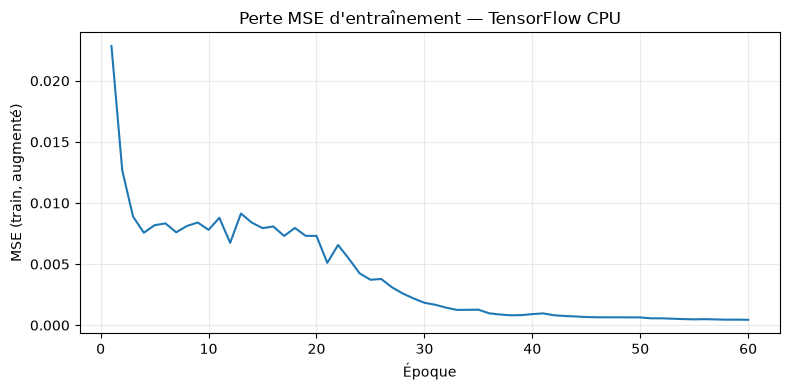

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history)
ax.set(title="Perte MSE d'entraînement — TensorFlow CPU", xlabel='Époque', ylabel='MSE (train, augmenté)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Calibrer le seuil et évaluer la détection d'anomalie

L'erreur de reconstruction moyenne par image sert de score d'anomalie. Le seuil est calibré sur la
validation (saine uniquement) : `moyenne + 3 écarts-types`. Le test combine les images saines
(`label = 0`) et toutes les catégories de défauts (`label = 1`).

In [6]:
def reconstruct(images_hwc, model, batch_size=32):
    return model.predict(images_hwc.astype(np.float32), batch_size=batch_size, verbose=0)


validation_reconstruction = reconstruct(validation_images, model)
validation_errors = reconstruction_error(validation_images, validation_reconstruction)
threshold = choose_threshold(validation_errors, n_std=3.0)

test_images_by_group = {'good': test_good_images, **test_defect_images}
test_errors_by_group = {}
for group_name, images in test_images_by_group.items():
    reconstruction = reconstruct(images, model)
    test_errors_by_group[group_name] = reconstruction_error(images, reconstruction)

test_labels = np.concatenate([
    np.zeros(len(test_errors_by_group['good']), dtype=int),
    *[np.ones(len(test_errors_by_group[d]), dtype=int) for d in defect_categories],
])
test_scores = np.concatenate([test_errors_by_group['good']] + [test_errors_by_group[d] for d in defect_categories])

ranking = ranking_metrics(test_labels, test_scores)
threshold_metrics = evaluate_at_threshold(test_labels, test_scores, threshold)
mean_error_by_defect = {group: float(errors.mean()) for group, errors in test_errors_by_group.items()}

from tabulate import tabulate
print(f'Seuil (validation, moyenne + 3 écarts-types) : {threshold:.6f}')
print(f"ROC-AUC test : {ranking['roc_auc']:.4f} ; PR-AUC test : {ranking['pr_auc']:.4f}\n")
print(tabulate(
    [[group, f'{err:.6f}'] for group, err in mean_error_by_defect.items()],
    headers=['Groupe', 'Erreur de reconstruction moyenne'], tablefmt='github',
))
print()
print(tabulate(
    [[threshold_metrics.precision, threshold_metrics.recall, threshold_metrics.f1,
      threshold_metrics.true_positive, threshold_metrics.true_negative,
      threshold_metrics.false_positive, threshold_metrics.false_negative]],
    headers=['Précision', 'Rappel', 'F1', 'VP', 'VN', 'FP', 'FN'], tablefmt='github',
))

Seuil (validation, moyenne + 3 écarts-types) : 0.001323
ROC-AUC test : 0.9605 ; PR-AUC test : 0.9877

| Groupe   |   Erreur de reconstruction moyenne |
|----------|------------------------------------|
| good     |                           0.000378 |
| color    |                           0.000711 |
| combined |                           0.000807 |
| hole     |                           0.000862 |
| liquid   |                           0.000619 |
| scratch  |                           0.000892 |

|   Précision |   Rappel |       F1 |   VP |   VN |   FP |   FN |
|-------------|----------|----------|------|------|------|------|
|           1 | 0.116667 | 0.208955 |    7 |   19 |    0 |   53 |


## Lecture du résultat précédent : le seuil détecte-t-il les défauts ?

Le classement reste très bon : **ROC-AUC = 0,9605**, **PR-AUC = 0,9877**. Au seuil calibré (`moyenne + 3 écarts-types`, soit **0,001323**), la détection réelle est très différente : **précision = 1,00**, **rappel = 0,12** — seulement **7** défauts détectés sur **60**, avec **0** fausse alerte. Même constat qu'en PyTorch : un excellent ROC-AUC/PR-AUC ne garantit pas un bon compromis au seuil choisi.

Le détail par catégorie confirme le même classement de difficulté observé aux autres exécutions : l'erreur moyenne des saines de test est **0,000378**, celle de `liquid` (**0,000619**) reste la plus proche de cette référence (le défaut le plus discret), `scratch` (**0,000892**) et `hole` (**0,000862**) s'en écartent le plus.

Ces valeurs (ROC-AUC, seuil, erreurs moyennes) diffèrent de celles obtenues lors d'une exécution antérieure de ce même notebook (ROC-AUC alors 0,9825) — cohérent avec la non-reproductibilité de TensorFlow/Keras CPU relevée ci-dessus : le nombre de défauts détectés au seuil (7 sur 60) et la conclusion qualitative restent toutefois inchangés.

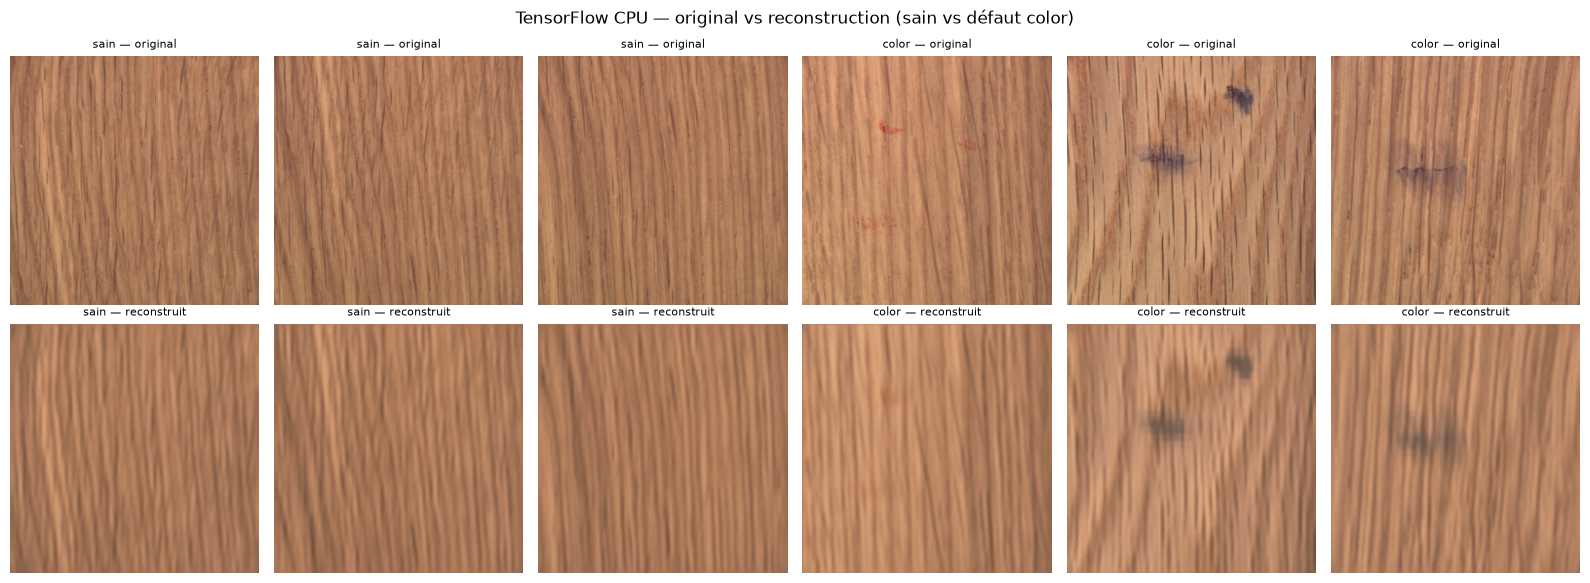

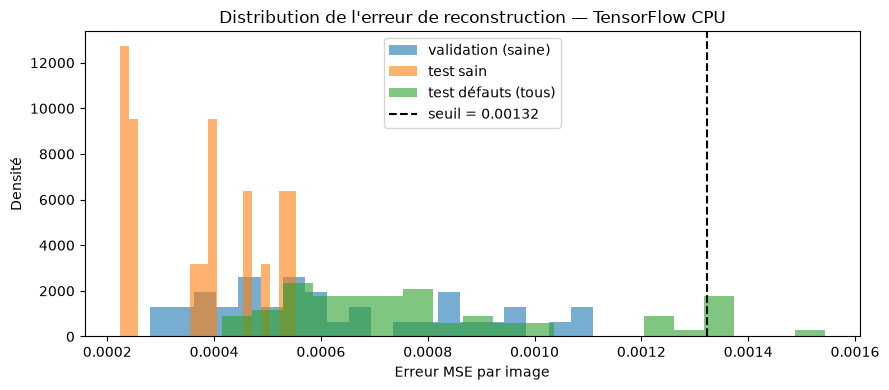

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
sample_good = test_good_images[:3]
sample_good_recon = reconstruct(sample_good, model)
sample_defect_name = defect_categories[0]
sample_defect = test_images_by_group[sample_defect_name][:3]
sample_defect_recon = reconstruct(sample_defect, model)

for col in range(3):
    axes[0, col].imshow(np.clip(sample_good[col], 0, 1)); axes[0, col].set_title('sain — original', fontsize=8); axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(sample_good_recon[col], 0, 1)); axes[1, col].set_title('sain — reconstruit', fontsize=8); axes[1, col].axis('off')
for col in range(3):
    axes[0, col + 3].imshow(np.clip(sample_defect[col], 0, 1)); axes[0, col + 3].set_title(f'{sample_defect_name} — original', fontsize=8); axes[0, col + 3].axis('off')
    axes[1, col + 3].imshow(np.clip(sample_defect_recon[col], 0, 1)); axes[1, col + 3].set_title(f'{sample_defect_name} — reconstruit', fontsize=8); axes[1, col + 3].axis('off')
fig.suptitle(f'TensorFlow CPU — original vs reconstruction (sain vs défaut {sample_defect_name})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validation_errors, bins=20, alpha=0.6, label='validation (saine)', density=True)
ax.hist(test_errors_by_group['good'], bins=20, alpha=0.6, label='test sain', density=True)
all_defect_errors = np.concatenate([test_errors_by_group[d] for d in defect_categories])
ax.hist(all_defect_errors, bins=20, alpha=0.6, label='test défauts (tous)', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'seuil = {threshold:.5f}')
ax.set(title="Distribution de l'erreur de reconstruction — TensorFlow CPU", xlabel='Erreur MSE par image', ylabel='Densité')
ax.legend()
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que montrent les reconstructions ?

Les reconstructions TensorFlow sont visuellement très proches des reconstructions PyTorch sur les
mêmes images : grain lissé pour les saines, petites marques `color` largement effacées, taches plus
grandes partiellement reproduites (floutées). Les deux frameworks convergent donc vers un comportement
de reconstruction similaire malgré des poids différents, ce qui renforce la confiance dans le résultat :
il reflète l'architecture et les données, pas un artefact d'implémentation.

L'histogramme montre le même chevauchement important entre erreurs du test sain et du test défauts que
côté PyTorch, avec un seuil très à droite ne capturant que la queue extrême des défauts — cohérent avec
le rappel tout aussi faible mesuré ci-dessus.

## Visualiser les détections au seuil retenu (vrais positifs, faux négatifs)

Conseil de la formatrice : au-delà des exemples génériques sain/défaut ci-dessus (choisis sans lien
avec le seuil), il est plus parlant d'inspecter concrètement **les images que le modèle classe
réellement** au seuil calibré (`moyenne + 3 écarts-types`) :

- **Vrais positifs (VP)** : images de défaut correctement signalées (`label = 1` et score ≥ seuil).
- **Faux négatifs (FN)** : images de défaut classées à tort comme **saines** (`label = 1` et
  score < seuil) — ce sont les défauts qui passeraient inaperçus en production, l'angle mort direct
  du faible rappel mesuré ci-dessus.

Les VP sont triés par score décroissant (détections les plus franches d'abord) ; les FN aussi, par
score décroissant parmi les ratés (les plus proches du seuil — les « presque détectés » — d'abord).

Défauts détectés (vrais positifs) : 7 / 60
Défauts classés sains (faux négatifs) : 53 / 60


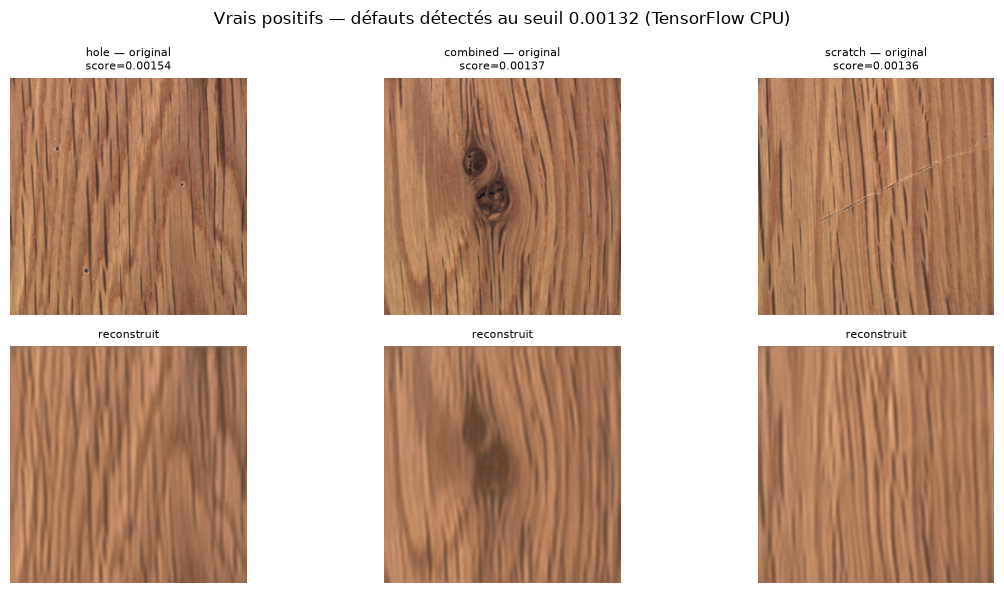

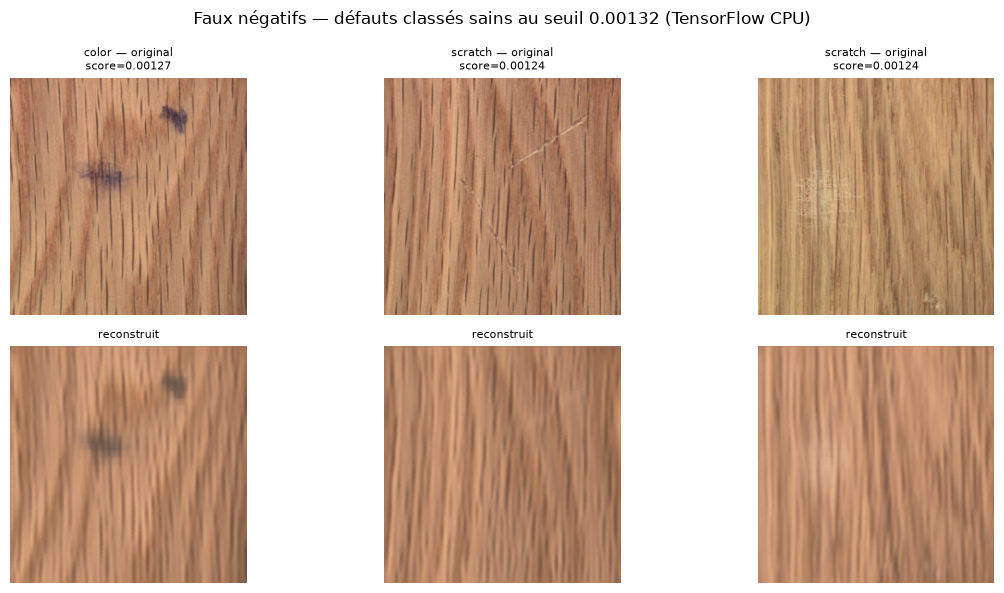

In [8]:
predictions = (test_scores >= threshold).astype(int)
test_group_names = np.array(
    ['good'] * len(test_errors_by_group['good'])
    + [defect for defect in defect_categories for _ in range(len(test_errors_by_group[defect]))]
)
test_images_concat = np.concatenate(
    [test_images_by_group['good']] + [test_images_by_group[d] for d in defect_categories], axis=0
)

true_positive_indices = np.where((test_labels == 1) & (predictions == 1))[0]
false_negative_indices = np.where((test_labels == 1) & (predictions == 0))[0]
true_positive_indices = true_positive_indices[np.argsort(-test_scores[true_positive_indices])][:3]
false_negative_indices = false_negative_indices[np.argsort(-test_scores[false_negative_indices])][:3]

print(f'Défauts détectés (vrais positifs) : {int(((test_labels == 1) & (predictions == 1)).sum())} / {int((test_labels == 1).sum())}')
print(f'Défauts classés sains (faux négatifs) : {int(((test_labels == 1) & (predictions == 0)).sum())} / {int((test_labels == 1).sum())}')


def plot_detections(indices, title):
    if len(indices) == 0:
        print(f'{title} : aucune image (0 cas au seuil retenu).')
        return
    imgs = test_images_concat[indices]
    reconstructed = reconstruct(imgs, model)
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 6), squeeze=False)
    for col, idx in enumerate(indices):
        axes[0, col].imshow(np.clip(imgs[col], 0, 1))
        axes[0, col].set_title(f'{test_group_names[idx]} — original\nscore={test_scores[idx]:.5f}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(np.clip(reconstructed[col], 0, 1))
        axes[1, col].set_title('reconstruit', fontsize=8)
        axes[1, col].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_detections(true_positive_indices, f'Vrais positifs — défauts détectés au seuil {threshold:.5f} (TensorFlow CPU)')
plot_detections(false_negative_indices, f'Faux négatifs — défauts classés sains au seuil {threshold:.5f} (TensorFlow CPU)')

## Lecture du résultat précédent : que montrent ces détections ?

**7** défauts sur 60 sont détectés (vrais positifs) et **53** sont classés à tort comme sains (faux négatifs) — cohérent avec le rappel de 0,12 mesuré ci-dessus. Les vrais positifs affichés sont les 3 défauts au score le plus élevé : ce sont les cas où l'écart visuel entre original et reconstruction est le plus franc, ce qui explique qu'ils dépassent le seuil malgré sa position très conservatrice dans la distribution des erreurs.

Les faux négatifs affichés sont, à l'inverse, les défauts **les plus proches du seuil parmi les ratés** : leur reconstruction est visuellement presque aussi fidèle que celle d'une image saine, ce qui illustre concrètement pourquoi `moyenne + 3 écarts-types` est une politique trop conservatrice ici — ces défauts existent bien mais produisent une erreur de reconstruction trop proche de celle des saines pour franchir ce seuil précis.

In [9]:
run = TrainingRun(
    framework='tensorflow',
    device='cpu',
    category=CATEGORY,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    trainable_parameters=trainable_parameters,
    first_epoch_seconds=first_epoch_seconds,
    train_seconds=train_seconds,
    seconds_per_epoch=steady_state_seconds_per_epoch,
    final_train_loss=loss_history[-1],
    validation_error_mean=float(validation_errors.mean()),
    validation_error_std=float(validation_errors.std()),
    threshold=threshold,
    roc_auc=ranking['roc_auc'],
    pr_auc=ranking['pr_auc'],
    metrics_at_threshold=threshold_metrics,
    mean_error_by_defect=mean_error_by_defect,
)
run_path = PROJECT_ROOT / "outputs/deep-learning/tensorflow-cpu.json"
run.to_json(run_path)
print(f'Résultats sauvegardés : {run_path}')
print(f'Première époque : {first_epoch_seconds:.3f} s, croisière : {steady_state_seconds_per_epoch*1000:.1f} ms/époque, total : {train_seconds:.3f} s')

Résultats sauvegardés : D:\source\A4U\FormationIA\indusense\outputs\deep-learning\tensorflow-cpu.json
Première époque : 3.034 s, croisière : 2390.1 ms/époque, total : 144.051 s


## Synthèse

Entraînement TensorFlow/Keras CPU de l'auto-encodeur convolutif (mêmes hyperparamètres et même
architecture que les deux versions PyTorch). Résultats détaillés ci-dessus, comparaison consolidée
dans [`02d-comparaison-frameworks-devices.ipynb`](02d-comparaison-frameworks-devices.ipynb).